# 1. 预测房价

In [55]:
import hashlib
import os
import tarfile
import zipfile
import requests
 
#@save
DATA_HUB = dict()
"""
这个字典可以将数据集名称的字符串映射到数据集相关的二元组上，这个二元组包含数据集的url和验证文件完整性的sha-1密钥（用来确定下载的数据集是否完整正确）。
"""
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'


In [56]:
def download(name, cache_dir=os.path.join('..', 'data')):  #@save
    """下载一个DATA_HUB中的文件，返回本地文件名"""
    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}"
    url, sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True)
    fname = os.path.join(cache_dir, url.split('/')[-1])
    if os.path.exists(fname):
        sha1 = hashlib.sha1()
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576)
                if not data:
                    break
                sha1.update(data)
        if sha1.hexdigest() == sha1_hash:
            return fname  # 命中缓存
    print(f'正在从{url}下载{fname}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

In [57]:
def download_extract(name, folder=None):  #@save
    """下载并解压zip/tar文件"""
    fname = download(name)
    base_dir = os.path.dirname(fname)
    data_dir, ext = os.path.splitext(fname)
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, '只有zip/tar文件可以被解压缩'
    fp.extractall(base_dir)
    return os.path.join(base_dir, folder) if folder else data_dir
 
def download_all():  #@save
    """下载DATA_HUB中的所有文件"""
    for name in DATA_HUB:
        download(name)

## 访问和读取数据集

In [58]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

In [59]:
DATA_HUB['kaggle_house_train'] = (
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce'
)

DATA_HUB['kaggle_house_test'] = (
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90'
)

In [60]:
train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

In [61]:
print(train_data.shape)
print(test_data.shape)

(1460, 81)
(1459, 80)


In [62]:
print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [63]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:])) # 将ID列删除，对预测并没有影响

## 数据预处理
在数据集中，我们有各式各样的数据类型。在开始建模之前，我们需要对数据进行预处理。首先，我们将所有缺失值替换为相应特征的平均值。然后，为了将所有特征放在一个共同的尺度上，我们通过将特征重新缩放到零均值和单位方差来标准化数据。
$$
x \longleftarrow  \frac{x - \mu}{\sigma}
$$
这样做有两个原因：首先，它方便优化；其次，因为我们不知道哪些特征是相关的，所以我们不想将惩罚分配给一个特征的系数比分配给其他任何特征的系数大。

In [64]:
# 若无法获取测试数据，可根据训练数据计算均值和标准差
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
"""
all_features.dtypes：获取DataFrame中每列的数据类型
all_features.dtypes != 'object'：找出不是object类型（即非字符串/文本）的列，这些是数值型列
numeric_features 是一个包含所有数值型特征列名的列表
"""

all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))
"""
(x - x.mean()) / (x.std())：Z-score标准化公式
将数据转换为均值为0、标准差为1的标准正态分布形式
"""

all_features[numeric_features] = all_features[numeric_features].fillna(0)

接下来，我们处理离散值，这包括诸如MSZoning之类的特征，我么用独热编码替换它们。

In [65]:
# ummy_na = True 将na（缺失值）视为有效的特征值，并为其创建指示符特征
all_features = pd.get_dummies(all_features, dummy_na = True)
"""
pd.get_dummies() 的作用:将分类变量（object类型或category类型）转换为虚拟变量/指示变量。
dummy_na = True 参数作用：将缺失值（NaN）也视为一个独立的类别
"""
all_features.shape

(2919, 330)

In [66]:
all_features = all_features.astype('float32')
n_train = train_data.shape[0]
# print(n_train, train_data.shape, all_features.shape)
train_features = torch.tensor(all_features[:n_train].values, dtype = torch.float32)
test_features = torch.tensor(all_features[n_train:].values, dtype = torch.float32)
train_labels = torch.tensor(
    train_data.SalePrice.values.reshape(-1, 1), dtype = torch.float32)

## 训练
首先，我们训练一个带有损失平方的线性模型。显然线性模型很难让我们在竞赛中获胜，但线性模型提供了一种健全性检查，以查看数据中是否存在有意义的信息。如果我们在这里不能做得比随机猜测更好，那么很可能存在数据处理错误。如果一切顺利，线性模型将作为**基线模型**，它可以让我们直观地直到最好的模型比简单模型好多少。

In [67]:
loss = nn.MSELoss()
in_features = train_features.shape[1]
# print(in_features, train_features.shape)
def get_net():
    net = nn.Sequential(nn.Linear(in_features, 1))
    return net

房价就像股票价格，我们关心的是相对数量，而不是绝对数量。因此，我们更关心相对误差$\frac{y - \hat y}{y}$，而不是角度误差$y - \hat y$。

解决这个问题的一种方法是用价格预测的对数来度量差异，事实上，这也是比赛中官方用来评价提交质量的误差指标，即将满足$|logy-log \hat y| \le \delta$的$\delta$准换为$e^{- \delta} \le \hat y - y \le e ^{\delta}$。这使得预测价格的对数与真是标签价格的对数之间出现以下均方根误差：
$$
\sqrt{\frac{1}{n} \sum_{i = 1}^{n}(logy_i - log \hat y_i)^2}
$$

In [68]:
def log_rmse(net, features, labels):
    # 为了在取对数时进一步稳定该值，将小于的1值设置为1
    clipped_preds = torch.clamp(net(features), 1, float('inf'))
    rmse = torch.sqrt(loss(torch.log(clipped_preds), torch.log(labels)))

    return rmse.item()

与前面的部分不同，我们的训练函数将借助Adam优化器。Adam优化器的主要吸引力在于对它初始学习率不那么敏感。

In [69]:
def train(net, train_features, train_labels, test_features, test_labels, 
         num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], [] # train_ls, test_ls: 存储每轮训练和测试的损失值
    train_iter = d2l.load_array((train_features, train_labels), batch_size)

    # 这里使用的是Adam优化器
    optimizer = torch.optim.Adam(net.parameters(), lr = learning_rate, weight_decay = weight_decay) # weight_decay: L2正则化，防止过拟合

    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad() # 1. 梯度清零
            l = loss(net(X), y) # 2. 前向传播 + 计算损失
            l.backward() # 3. 反向传播计算梯度
            optimizer.step() # 4. 更新参数
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

## K折交叉验证
K折交叉验证有助于模型选择和超参数调整。注意这不是处理数据的最有效方法，如果我们的数据集大得多，还有其他解决办法。

In [70]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size) # 创建切片对象,取出这一部分数据的id
        X_part, y_part = X[idx, :], y[idx]
        if j == i: 
            X_valid, y_valid = X_part, y_part  # 第i折作为验证集
        elif X_train is None:
            X_train, y_train = X_part, y_part # 第一次遇到训练集时初始化
        else: 
            X_train = torch.cat([X_train, X_part], 0)  # 后续训练集拼接
            y_train = torch.cat([y_train, y_part], 0)
    return X_train, y_train, X_valid, y_valid

当我们在K折交叉验证中训练K次后，返回训练和验证误差的平均值

In [71]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate, weight_decay, batch_size)

        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]

        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls], xlabel = 'epoch', 
                     ylabel = 'rmse', xlim = [1, num_epochs], legend = ['train', 'valid'], yscale = 'log')
        print(f'折{i+1}， 训练log rmse{float(train_ls[-1]):f}, '  f'验证log rmse {float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

## 模型选择

折1， 训练log rmse0.170048, 验证log rmse 0.156477
折2， 训练log rmse0.162271, 验证log rmse 0.191048
折3， 训练log rmse0.164150, 验证log rmse 0.168351
折4， 训练log rmse0.168167, 验证log rmse 0.154591
折5， 训练log rmse0.163102, 验证log rmse 0.182783
5-折验证：平均训练log rmse：0.165548, 平均验证log rmse:0.170650


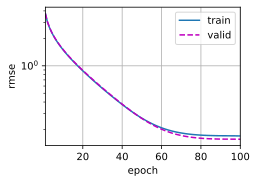

In [83]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr, weight_decay, batch_size)

print(f'{k}-折验证：平均训练log rmse：{float(train_l):f}, '
     f'平均验证log rmse:{float(valid_l):f}')

In [73]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集。
    preds = net(test_features).detach().numpy()
    # 将其重新格式化以导出到Kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0])
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1)
    submission.to_csv('submission.csv', index=False)

训练log rmse：0.162345


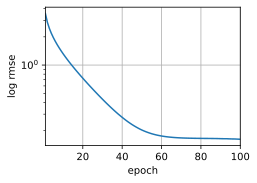

In [74]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)